In [ ]:
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:alessandro-strada/ppa 2>&1 > /dev/null
!apt-get update -qq 2>&1 > /dev/null
!apt-get -y install -qq google-drive-ocamlfuse fuse
from google.colab import auth
auth.authenticate_user()
from oauth2client.client import GoogleCredentials
creds = GoogleCredentials.get_application_default()
import getpass
!google-drive-ocamlfuse -headless -id={creds.client_id} -secret={creds.client_secret} < /dev/null 2>&1 | grep URL
vcode = getpass.getpass()
!echo {vcode} | google-drive-ocamlfuse -headless -id={creds.client_id} -secret={creds.client_secret}
%cd /content
!mkdir drive
%cd drive
!mkdir MyDrive
%cd ..
%cd ..
!google-drive-ocamlfuse /content/drive/MyDrive

E: Package 'python-software-properties' has no installation candidate
Selecting previously unselected package google-drive-ocamlfuse.
(Reading database ... 155335 files and directories currently installed.)
Preparing to unpack .../google-drive-ocamlfuse_0.7.27-0ubuntu1~ubuntu18.04.1_amd64.deb ...
Unpacking google-drive-ocamlfuse (0.7.27-0ubuntu1~ubuntu18.04.1) ...
Setting up google-drive-ocamlfuse (0.7.27-0ubuntu1~ubuntu18.04.1) ...
Processing triggers for man-db (2.8.3-2ubuntu0.1) ...
Please, open the following URL in a web browser: https://accounts.google.com/o/oauth2/auth?client_id=32555940559.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive&response_type=code&access_type=offline&approval_prompt=force
··········
Please, open the following URL in a web browser: https://accounts.google.com/o/oauth2/auth?client_id=32555940559.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope

In [ ]:
import pandas as pd
import numpy as np
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # this is used for the plot the graph
import os
import seaborn as sns # used for plot interactive graph.
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report
import sklearn.metrics.cluster as smc
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import KFold, RepeatedStratifiedKFold
from matplotlib import pyplot
import itertools
%matplotlib inline
import random

In [ ]:
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
  path = os.path.join(fig_id + "." + fig_extension)
  print("Saving figure", fig_id)
  if tight_layout:
    plt.tight_layout()
  plt.savefig(path, format=fig_extension, dpi=resolution)

In [ ]:
import itertools
def draw_confusion_matrix(y, yhat, classes):
  '''
      Draws a confusion matrix for the given target and predictions
      Adapted from scikit-learn and discussion example.
  '''
  plt.cla()
  plt.clf()
  matrix = confusion_matrix(y, yhat)
  plt.imshow(matrix, interpolation='nearest', cmap=plt.cm.Blues)
  plt.title("Confusion Matrix")
  plt.colorbar()
  num_classes = len(classes)
  plt.xticks(np.arange(num_classes), classes, rotation=90)
  plt.yticks(np.arange(num_classes), classes)
  fmt = 'd'
  thresh = matrix.max() / 2.
  for i, j in itertools.product(range(matrix.shape[0]), range(matrix.shape[1])):
    plt.text(j, i, format(matrix[i, j], fmt), horizontalalignment="center",
              color="white" if matrix[i, j] > thresh else "black")
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()
  plt.show()

In [ ]:
def report( y_test_predict, y_test ):
  accuracy_score = metrics.accuracy_score(y_test_predict, y_test)
  precision_score = metrics.precision_score(y_test_predict, y_test)
  recall_score = metrics.recall_score(y_test_predict, y_test)
  f1_score = metrics.f1_score(y_test_predict, y_test)

  print(f"Accuracy score = {accuracy_score}")
  print(f"Precision score = {precision_score}")
  print(f"Recall score = {recall_score}")
  print(f"F1 score = {f1_score}")
  print("Confusion matrix: \n")
  draw_confusion_matrix( y_test, y_test_predict, ['Not Fraud','Fraud'] )
def ROC_draw( y_test_predict, y_test, model ):
  fpr, tpr, threshold = metrics.roc_curve( y_test, y_test_predict, pos_label = 1 )
  pyplot.plot( fpr, tpr )
  pyplot.xlabel("FPR")
  pyplot.ylabel("TPR")
  pyplot.title(f"ROC curve of {model} model")
  pyplot.show()

In [ ]:
# LOADING AND EXPLORING THE DATA

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/AAADDD/transaction_dataset.csv")

In [ ]:
pd.set_option('display.max_column', None)
data.head()

,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.00,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.0,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.00,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.05,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,None,XENON
3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.00,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.0,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.00,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.0,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [ ]:
# Drop the first two meaningless columns
data.drop(['Index', 'Address'], axis=1, inplace=True)

In [ ]:
data.shape

(9841, 48)

In [ ]:
# Data informations
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 48 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   FLAG                                                  9841 non-null   int64  
 1   Avg min between sent tnx                              9841 non-null   float64
 2   Avg min between received tnx                          9841 non-null   float64
 3   Time Diff between first and last (Mins)               9841 non-null   float64
 4   Sent tnx                                              9841 non-null   int64  
 5   Received Tnx                                          9841 non-null   int64  
 6   Number of Created Contracts                           9841 non-null   int64  
 7   Unique Received From Addresses                        9841 non-null   int64  
 8   Unique Sent To Addresses                              9841

In [ ]:
data.describe()

,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,max value received,avg val received,min val sent,max val sent,avg val sent,min value sent to contract,max val sent to contract,avg value sent to contract,total transactions (including tnx to create contract,total Ether sent,total ether received,total ether sent contracts,total ether balance,Total ERC20 tnxs,ERC20 total Ether received,ERC20 total ether sent,ERC20 total Ether sent contract,ERC20 uniq sent addr,ERC20 uniq rec addr,ERC20 uniq sent addr.1,ERC20 uniq rec contract addr,ERC20 avg time between sent tnx,ERC20 avg time between rec tnx,ERC20 avg time between rec 2 tnx,ERC20 avg time between contract tnx,ERC20 min val rec,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name
count,9841.000000,9841.000000,9841.000000,9.841000e+03,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9.841000e+03,9.841000e+03,9841.000000,9.841000e+03,9012.000000,9.012000e+03,9.012000e+03,9012.000000,9012.000000,9012.000000,9012.000000,9012.000000,9012.0,9012.0,9012.0,9012.0,9012.000000,9.012000e+03,9.012000e+03,9.012000e+03,9.012000e+03,9.012000e+03,9012.0,9012.0,9012.0,9012.000000,9012.000000
mean,0.221421,5086.878721,8004.851184,2.183333e+05,115.931714,163.700945,3.729702,30.360939,25.840159,43.845153,523.152481,100.711721,4.800090,314.617297,44.755731,0.000003,0.000008,0.000005,283.362362,1.016092e+04,1.163832e+04,0.000008,1.477395e+03,36.255659,1.296207e+08,1.386849e+07,110.939207,5.638038,7.598535,0.003440,4.901909,0.0,0.0,0.0,0.0,485.614688,1.252524e+08,4.346203e+06,1.174126e+04,1.303594e+07,6.318389e+06,0.0,0.0,0.0,1.384931,4.826676
std,0.415224,21486.549974,23081.714801,3.229379e+05,757.226361,940.836550,141.445583,298.621112,263.820410,325.929139,13008.821539,2885.002236,138.609682,6629.212643,239.080215,0.000225,0.000516,0.000323,1352.404013,3.583227e+05,3.642048e+05,0.000516,2.424254e+05,447.528908,1.053858e+10,1.180390e+09,6128.634953,105.252500,81.818470,0.065698,17.246576,0.0,0.0,0.0,0.0,16883.278712,1.053741e+10,2.141192e+08,1.053567e+06,1.179905e+09,5.914764e+08,0.0,0.0,0.0,6.735121,16.678607
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,-1.560535e+07,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
25%,0.000000,0.000000,0.000000,3.169300e+02,1.000000,1.000000,0.000000,1.000000,1.000000,0.001000,1.000000,0.426905,0.000000,0.164577,0.086184,0.000000,0.000000,0.000000,4.000000,2.262059e-01,2.670424e+00,0.000000,6.214900e-04,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
50%,0.000000,17.340000,509.770000,4.663703e+04,3.000000,4.000000,0.000000,2.000000,2.000000,0.095856,6.000000,1.729730,0.049126,4.999380,1.606000,0.000000,0.000000,0.000000,8.000000,1.248680e+01,3.052963e+01,0.000000,1.722000e-03,1.000000,1.000000e-12,0.000000e+00,0.000000,0.000000,1.000000,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,1.000000
75%,0.000000,565.470000,5480.390000,3.040710e+05,11.000000,27.000000,0.000000,5.000000,3.000000,2.000000,67.067040,22.000000,0.998800,61.520653,21.999380,0.000

In [ ]:
# Explore the non-numerical features
items = data.select_dtypes(include=['object'])
items

,ERC20 most sent token type,ERC20_most_rec_token_type
0,Cofoundit,Numeraire
1,Livepeer Token,Livepeer Token
2,None,XENON
3,Raiden,XENON
4,StatusNetwork,EOS
...,...,...
9836,,GSENetwork
9837,,Blockwell say NOTSAFU
9838,,Free BOB Tokens - BobsRepair.com
9839,NaN,NaN


In [ ]:
for item in items.columns:
  print(f'{item} has {len(items[item].unique())} unique values')

 ERC20 most sent token type has 306 unique values
 ERC20_most_rec_token_type has 468 unique values


In [ ]:
# Drop the two of non-numerical columns
data.drop(items, axis=1, inplace=True)
data.shape

(9841, 46)

In [ ]:
# Explore the numerical features
# explore variance of the feature distributions
low_var = data.iloc[:, 1:].var()[data.iloc[:, 1:].var() == 0]
low_var.index

Index([' ERC20 avg time between sent tnx', ' ERC20 avg time between rec tnx',
       ' ERC20 avg time between rec 2 tnx',
       ' ERC20 avg time between contract tnx', ' ERC20 min val sent contract',
       ' ERC20 max val sent contract', ' ERC20 avg val sent contract'],
      dtype='object')

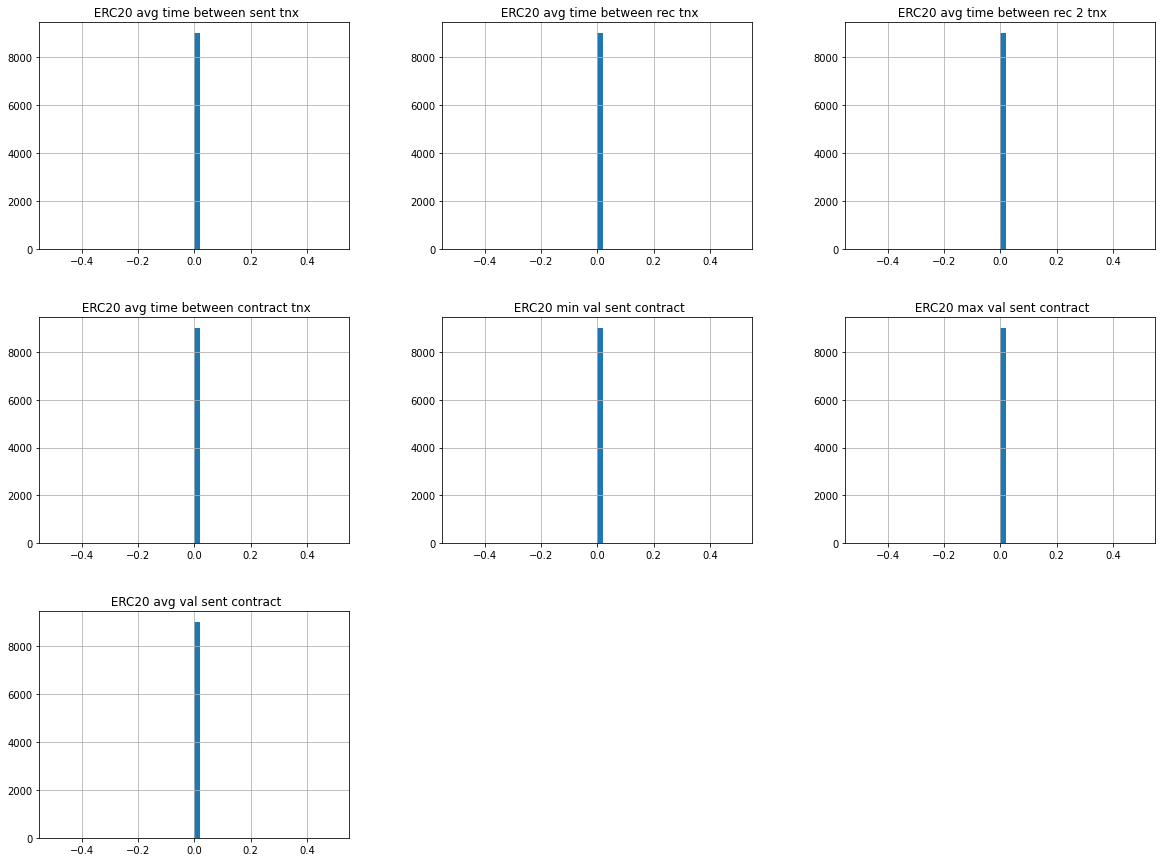

In [ ]:
# Plot all features have zero variance
data[low_var.index].hist(bins = 50, figsize = (20, 15))
plt.show()

In [ ]:
# Drop all features that have zero variances
data.drop(low_var.index, axis = 1, inplace=True)

In [ ]:
data.shape

(9841, 39)

In [ ]:
# Remove duplicated rows
data_dup = data[data.duplicated(keep= 'first')]
data.drop(index=data_dup.index, inplace=True)

In [ ]:
data.shape, data_dup.shape

((9288, 39), (553, 39))

In [ ]:
data.isnull().sum()[data.isnull().sum()>0]

 Total ERC20 tnxs                   549
 ERC20 total Ether received         549
 ERC20 total ether sent             549
 ERC20 total Ether sent contract    549
 ERC20 uniq sent addr               549
 ERC20 uniq rec addr                549
 ERC20 uniq sent addr.1             549
 ERC20 uniq rec contract addr       549
 ERC20 min val rec                  549
 ERC20 max val rec                  549
 ERC20 avg val rec                  549
 ERC20 min val sent                 549
 ERC20 max val sent                 549
 ERC20 avg val sent                 549
 ERC20 uniq sent token name         549
 ERC20 uniq rec token name          549
dtype: int64

In [ ]:
#Fill the missing value rows
data.fillna(data.mean(), inplace=True)
data.shape

(9288, 39)

In [ ]:
# Detecing Multicollinearity of predictors with VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['Features'] = data.iloc[:, 1:].columns
vif_data['VIF factors'] = [variance_inflation_factor(data.iloc[:, 1:].values, i)
                          for i in range(data.shape[1] - 1)]
data.drop(vif_data[vif_data['VIF factors'] > 8].Features, axis=1, inplace=True)

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm
/usr/local/lib/python3.7/dist-packages/statsmodels/stats/outliers_influence.py:185: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


In [ ]:
data.shape

(9288, 20)

1656	 stroke and 7632	 not stroke
17.829	 stroke and 82.171 not stroke (in percentage)


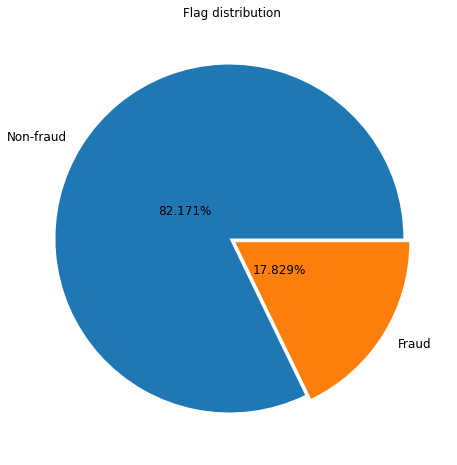

In [ ]:
#Explore the Flag distribution
Fraud = data[data == 1]["FLAG"].count()
Non_Fraud = data[data == 0]["FLAG"].count()
perFraud = Fraud / (Fraud + Non_Fraud)
perNonFraud = 1 - perFraud
print("%d\t fraud and %d\t not fraud" % ( Fraud, Non_Fraud))
print("%4.3f\t Fraud and %4.3f not fraud (in percentage)" % (perFraud*100, perNonFraud*100))
pie, ax = plt.subplots(figsize=[13,8])
labels = ['Non-fraud', 'Fraud']
plt.pie(x = data['FLAG'].value_counts(), autopct='%.3f%%', explode=[0.02]*2, labels=labels, pctdistance=0.3, textprops={'fontsize': 12})
plt.title('Flag distribution')
plt.show()

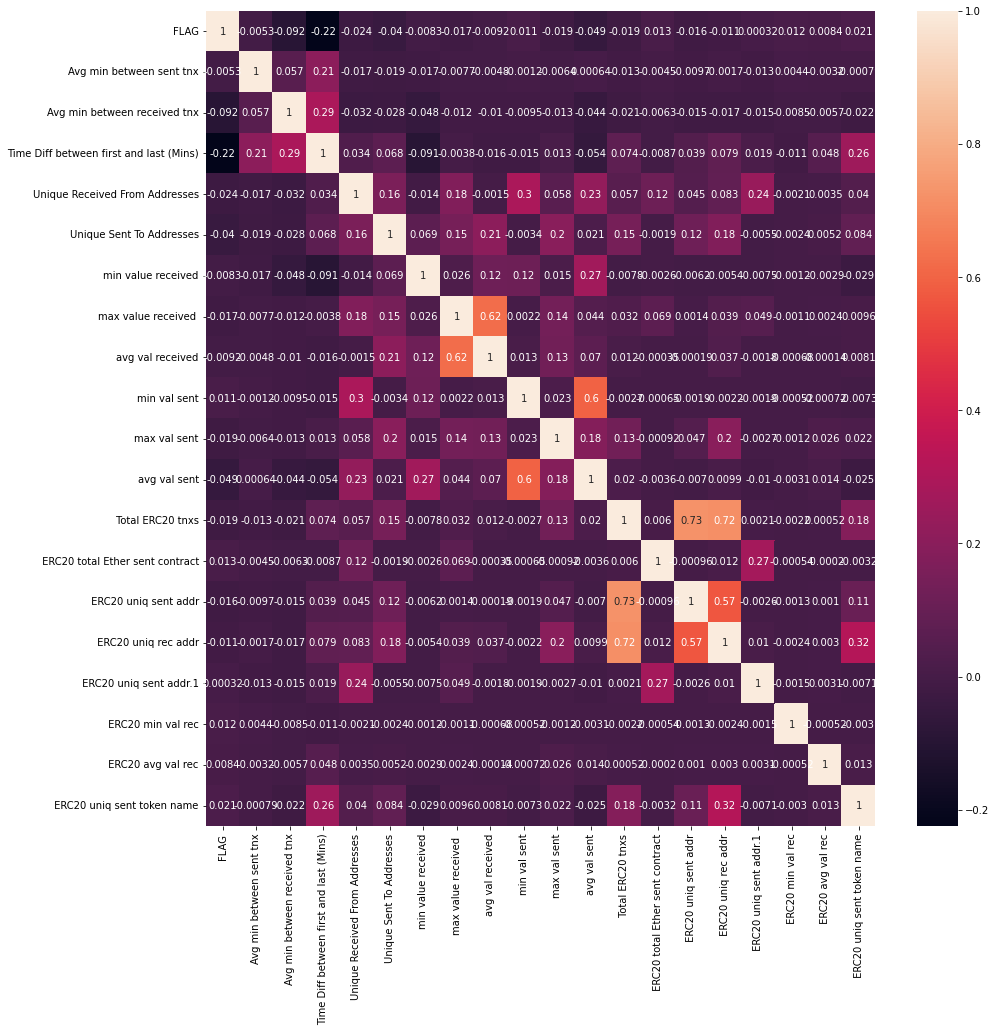

In [ ]:
# Explore the correlation matrix
correlation_matrix = data.corr()
plt.figure(figsize = (15, 15))
sns.heatmap(correlation_matrix, annot = True)

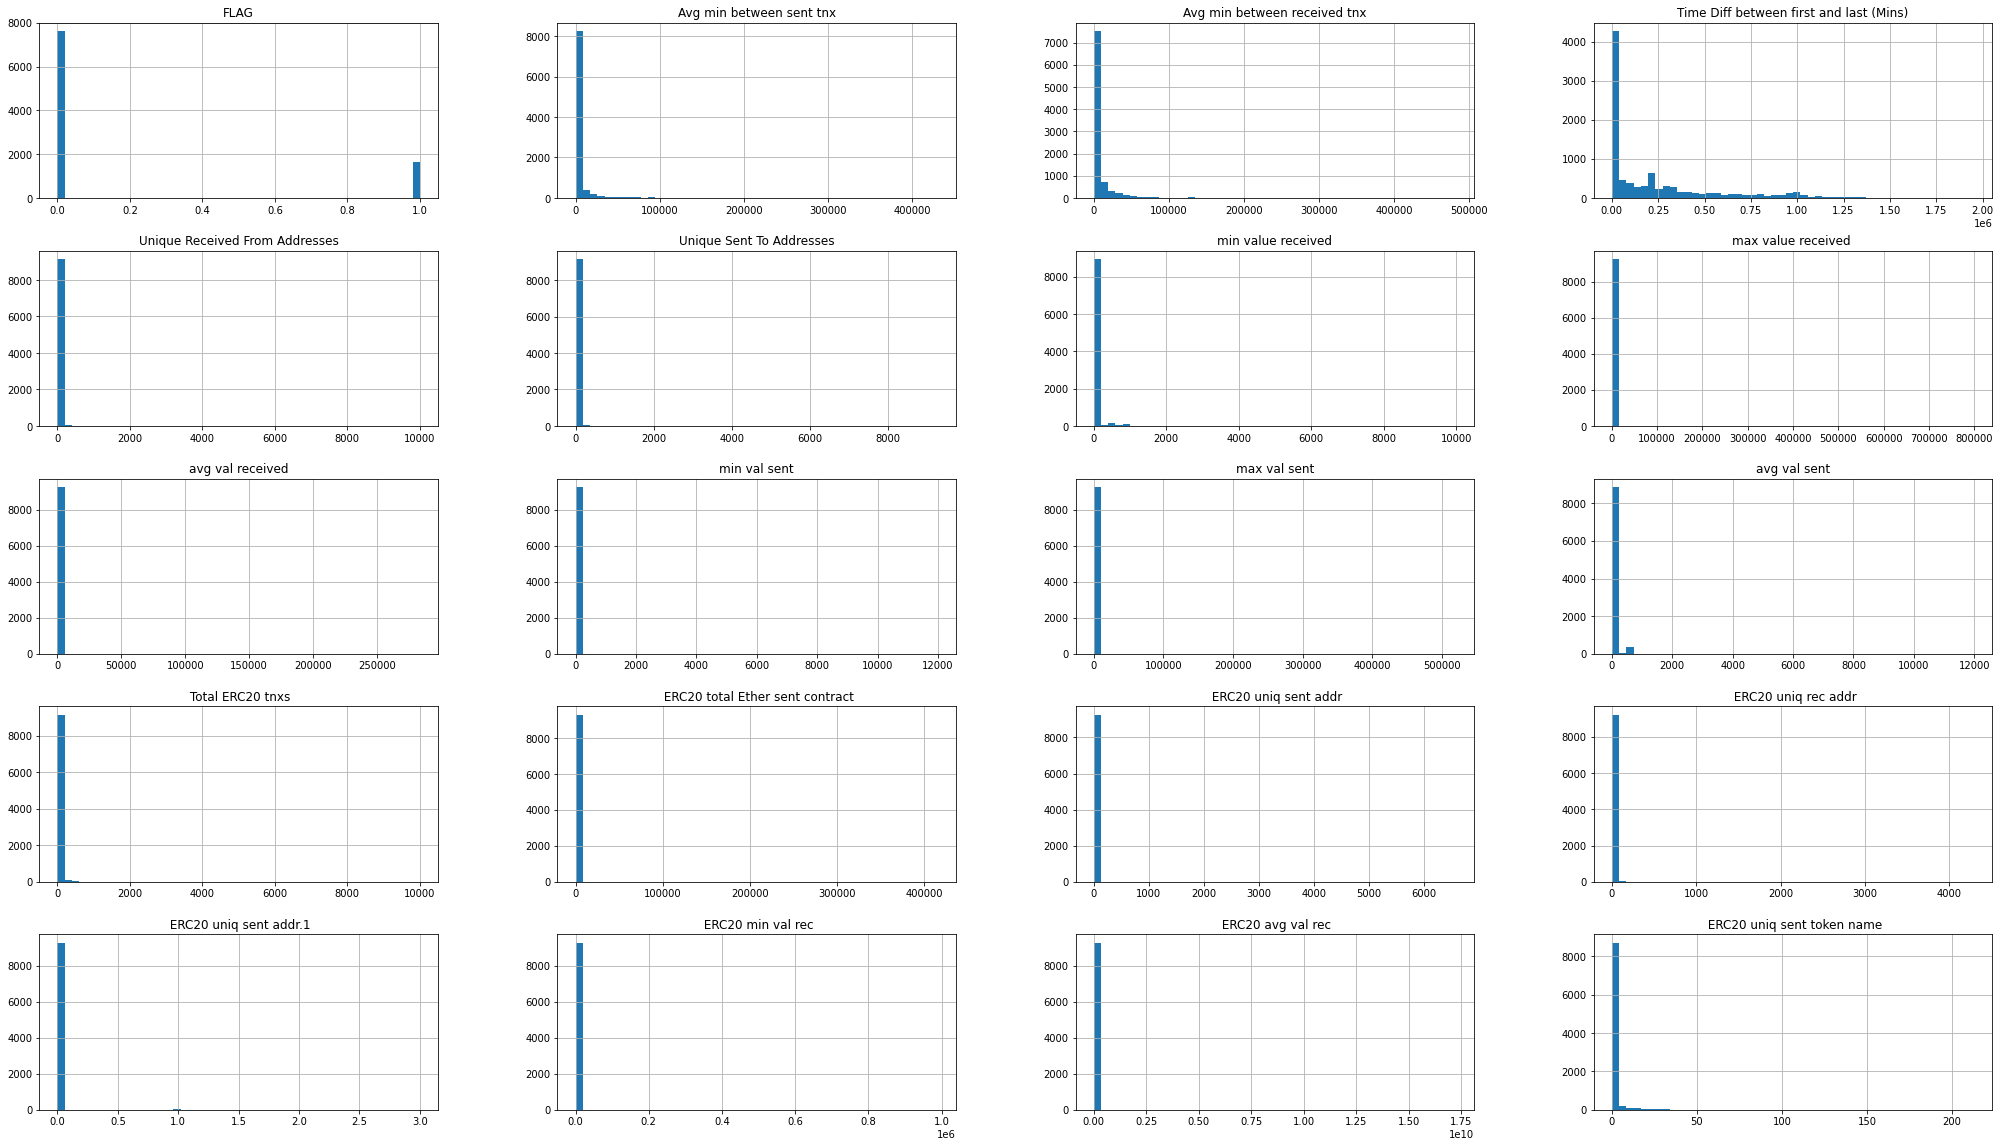

In [ ]:
# We can draw a histogram for each of the dataframes features # using the hist function
data.hist( bins = 50, figsize = ( 35, 20 ) )
# save_fig("attribute_histogram_plots")
plt.show() # pandas internally uses matplotlib, and to display all the figures
           # the show() function must be called

In [ ]:
# Part 2: feature extraction plan and implement pipeline

In [ ]:
y_dataset = data['FLAG']
X_dataset = data.drop('FLAG', axis=1)

In [ ]:
# Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
num_pipeline = Pipeline( [
('std_scaler', StandardScaler()) ])
full_pipeline = ColumnTransformer( [
("num", num_pipeline , X_dataset.columns)])
X_prepared = full_pipeline.fit_transform( X_dataset )
X_prepared.shape

(9288, 19)

In [ ]:
# Splitting data and handling imbalanced problem

from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
X_train, X_test, y_train, y_test = train_test_split( X_prepared, y_dataset, test_size = 0.2, random_state = 0,
shuffle = True )
counter = Counter(y_train)
print(counter)
oversample = SMOTE()
undersample = RandomUnderSampler()
X_train, y_train = oversample.fit_resample( X_train, y_train )
X_train, y_train = undersample.fit_resample( X_train, y_train )
counter = Counter(y_train)
print(counter)

Counter({0: 6081, 1: 1349})
Counter({0: 6081, 1: 6081})


In [ ]:
# Implement Principle Component Analysis (PCA)
from sklearn.decomposition import PCA
n= 12
pca = PCA(n_components = n)
X_pca_train = pca.fit_transform( X_train )
X_pca_test = pca.transform(X_test)
X_pca_prepared = pca.transform(X_prepared)
explained_variance = pca.explained_variance_ratio_
print(n, sum(explained_variance))
print(explained_variance)

12 0.870649670912996
[0.18223318 0.10496254 0.09949129 0.09350316 0.07490565 0.06859797
 0.05916391 0.0488492  0.0390571  0.03658194 0.03477984 0.02852388]


In [ ]:
type(y_dataset)

pandas.core.series.Series

In [ ]:
# Implement K_fold_test function
def K_fold_test( model, k ):
  accuracy_scores = []
  precision_scores = []
  recall_scores = []
  f1_scores = []
  folds = KFold(n_splits = k, shuffle = True, random_state = None)
  for train_idx, test_idx in folds.split( pd.DataFrame(X_prepared)):
    X_temp_train = X_prepared[train_idx,:]
    X_temp_test = X_prepared[test_idx,:]
    y_temp_train = np.array(y_dataset)[train_idx]
    y_temp_test = np.array(y_dataset)[test_idx]
    oversample = SMOTE()
    undersample = RandomUnderSampler()
    X_temp_train, y_temp_train = oversample.fit_resample( X_temp_train, y_temp_train )
    X_temp_train, y_temp_train = undersample.fit_resample( X_temp_train, y_temp_train )
    y_test_predict = model.fit( X_temp_train, y_temp_train ).predict( X_temp_test )
    accuracy_scores.append(metrics.accuracy_score( y_temp_test, y_test_predict ))
    precision_scores.append(metrics.precision_score( y_temp_test, y_test_predict ))
    recall_scores.append(metrics.recall_score( y_temp_test, y_test_predict ))
    f1_scores.append(metrics.f1_score( y_temp_test, y_test_predict ))
  print("Mean accuracy score: {}".format( sum( accuracy_scores ) / k ) )
  print("Mean precision score: {}".format( sum( precision_scores ) / k ) )
  print("Mean recall score: {}".format( sum( recall_scores ) / k ) )
  print("Mean f1 score: {}".format( sum( f1_scores ) / k ) )

In [ ]:
# Model Prediction
from xgboost import XGBClassifier
from xgboost import plot_importance
model = XGBClassifier(random_state=42, eval_metric='auc',
              objective='binary:logistic')
model.fit(X_train, y_train)


XGBClassifier(eval_metric='auc', random_state=42)

Accuracy score = 0.9666307857911733
Precision score = 0.9446254071661238
Recall score = 0.8656716417910447
F1 score = 0.9034267912772586
Confusion matrix: 



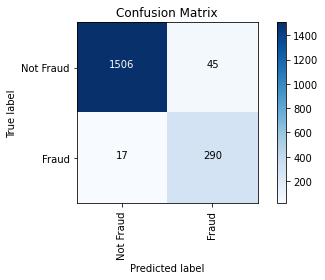

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1551
           1       0.87      0.94      0.90       307

    accuracy                           0.97      1858
   macro avg       0.93      0.96      0.94      1858
weighted avg       0.97      0.97      0.97      1858



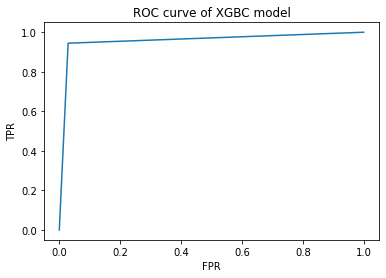

Mean accuracy score: 0.954133569652203
Mean precision score: 0.8316447037754946
Mean recall score: 0.9353281437981231
Mean f1 score: 0.8797691032091077


In [ ]:
y_test_predict = model.predict(X_test)
report( y_test_predict, y_test )
print(classification_report(y_test, y_test_predict))
ROC_draw( y_test_predict, y_test, "XGBC" )
K_fold_test( XGBClassifier( probability = True ), 10 )

In [ ]:
print(classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1551
           1       0.87      0.94      0.90       307

    accuracy                           0.97      1858
   macro avg       0.93      0.96      0.94      1858
weighted avg       0.97      0.97      0.97      1858



In [ ]:
def stacking():
	# define the base models
	level0 = list()
	level0.append(('lr', LogisticRegression()))
	level0.append(('knn', KNeighborsClassifier()))
	level0.append(('cart', DecisionTreeClassifier()))
	level0.append(('svm', SVC()))
	level0.append(('bayes', GaussianNB()))
	# define meta learner model
	level1 = LogisticRegression()
	# define the stacking ensemble
	model = StackingClassifier(estimators=level0, final_estimator=level1, cv=5)
	return model

In [ ]:
def get_models():
	models = dict()
	models['lr'] = LogisticRegression()
	models['knn'] = KNeighborsClassifier()
	models['cart'] = DecisionTreeClassifier()
	models['svm'] = SVC()
	models['xgboost'] = XGBClassifier()
	models['Stacking'] = stacking()
	return models

In [ ]:

# evaluate a given model using cross-validation
def evaluate_model(model, X, y):
	cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
	scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
	return scores

Accuracy: 0.68 (+/- 0.01) [lr]
Accuracy: 0.94 (+/- 0.01) [knn]
Accuracy: 0.98 (+/- 0.00) [cart]


/usr/local/lib/python3.7/dist-packages/joblib/externals/loky/process_executor.py:705: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  "timeout or by a memory leak.", UserWarning


Accuracy: 0.82 (+/- 0.01) [svm]
Accuracy: 0.98 (+/- 0.00) [xgboost]


/usr/local/lib/python3.7/dist-packages/joblib/externals/loky/process_executor.py:705: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  "timeout or by a memory leak.", UserWarning


Accuracy: 0.98 (+/- 0.00) [Stacking]


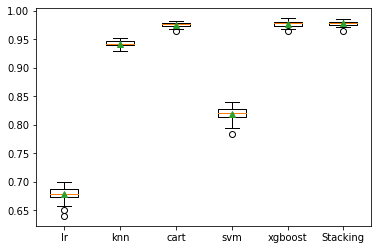

In [ ]:
models = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, model in models.items():
  scores = evaluate_model(model, X_train, y_train)
  results.append(scores)
  names.append(name)
  print("Accuracy: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), name))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()